## Anomaly Detection & Misuse Detection | NSL-KDD Dataset

## Setup

In [ ]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import auc, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

COLUMNS = [
    'duration','protocol_type','service','flag',
    'src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell',
    'su_attempted','num_root','num_file_creations','num_shells',
    'num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
    'count','srv_count','serror_rate','srv_serror_rate','rerror_rate',
    'srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','label','difficulty'
]

# Three symbolic (nominal/categorical) columns removed for distance calculation (mentioned in the assignment)
SYMBOLIC_COLS = ['protocol_type', 'service', 'flag']

#Difficulty is a meta-label indicating difficulty in classification, it's not considered for prediction as it's not really a feature (mentioned in the assignment)
NUMERIC_COLS  = [c for c in COLUMNS if c not in SYMBOLIC_COLS + ['label', 'difficulty']]

ATTACK_MAP = {
    'back':'dos','land':'dos','neptune':'dos','pod':'dos','smurf':'dos','teardrop':'dos',
    'ipsweep':'probe','nmap':'probe','portsweep':'probe','satan':'probe',
    'ftp_write':'r2l','guess_passwd':'r2l','imap':'r2l','multihop':'r2l',
    'phf':'r2l','spy':'r2l','warezclient':'r2l','warezmaster':'r2l',
    'buffer_overflow':'u2r','loadmodule':'u2r','perl':'u2r','rootkit':'u2r',
    'normal':'normal',
}
def map_attack(label):
    return ATTACK_MAP.get(label.strip().lower(), 'unknown')

CATEGORIES  = ['normal', 'probe', 'dos', 'u2r', 'r2l']
cat_to_idx  = {c: i for i, c in enumerate(CATEGORIES)}

COST_MATRIX = np.array([
    [0, 1, 2, 2, 2],
    [1, 0, 2, 2, 2],
    [2, 2, 0, 2, 2],
    [3, 3, 3, 0, 3],
    [4, 4, 4, 4, 0],
])

cost_matrix_df = pd.DataFrame(COST_MATRIX, index=CATEGORIES, columns=CATEGORIES)

train_df = pd.read_csv('20 Percent Training Set.csv', header=None, names=COLUMNS)

#KDDTest+.csv in the github is malformed (missing newlines), so we've used the equivalent .txt file.
test_df  = pd.read_csv('KDDTest+.txt', header=None, names=COLUMNS)
train_df.drop(columns=['difficulty'], inplace=True)
test_df.drop(columns=['difficulty'],  inplace=True)

X_test_raw    = test_df[NUMERIC_COLS].values
y_test_binary = (test_df['label'] != 'normal').astype(int).values

print(f"Training: {len(train_df):,} records | Test: {len(test_df):,} records")
print(f"Numeric features used: {len(NUMERIC_COLS)}")
print("\n")
print("Cost Matrix:")
display(cost_matrix_df)

Training: 25,192 records | Test: 22,544 records
Numeric features used: 38


Cost Matrix:


,normal,probe,dos,u2r,r2l
normal,0,1,2,2,2
probe,1,0,2,2,2
dos,2,2,0,2,2
u2r,3,3,3,0,3
r2l,4,4,4,4,0


---
# Part A: Anomaly Detection

### A(1) — Extract normal instances; normalize attribute values

In [4]:
train_normal       = train_df[train_df['label'] == 'normal']
X_train_normal_raw = train_normal[NUMERIC_COLS].values

scaler_A       = MinMaxScaler()
X_train_normal = scaler_A.fit_transform(X_train_normal_raw)
X_test_A       = scaler_A.transform(X_test_raw)

print(f"Normal training instances : {len(train_normal):,}")
print(f"Scaler range per feature  : [0, 1]  (Min-Max normalization)")


Normal training instances : 13,449
Scaler range per feature  : [0, 1]  (Min-Max normalization)


### A(2) — Find nearest normal neighbor & compute distance for each test instance

In [5]:
nn_model = NearestNeighbors(n_neighbors=1, algorithm='ball_tree', metric='euclidean', n_jobs=-1)
nn_model.fit(X_train_normal)
distances, _           = nn_model.kneighbors(X_test_A)
dist_to_nearest_normal = distances[:, 0]

pd.Series(dist_to_nearest_normal).describe().rename('Distance to Nearest Normal Neighbor')


count    22544.000000
mean         0.522235
std          0.623023
min          0.000000
25%          0.012485
50%          0.125837
75%          1.251234
max          7.199565
Name: Distance to Nearest Normal Neighbor, dtype: float64

### A(3) - Varying the control threshold; Classifying each new instance as normal or attack

In [6]:
#creating the thresholds
thresholds = np.linspace(
    dist_to_nearest_normal.min(),
    dist_to_nearest_normal.max(),
    10
)

#making the predictions
predictions_dict = {}

for t in thresholds:
    predictions_dict[t] = [
        0 if d <= t else 1
        for d in dist_to_nearest_normal
    ]

## Part B: Misuse Detection

### B(1) - Normalize full training set

In [7]:
# Use all training data
X_train_all_raw = train_df[NUMERIC_COLS].values
y_train_binary  = (train_df['label'] != 'normal').astype(int).values

# Fit scaler on full training set, apply same scaling to test set
scaler_B  = MinMaxScaler()
X_train_B = scaler_B.fit_transform(X_train_all_raw)
X_test_B  = scaler_B.transform(X_test_raw)
print(f"Training instances (all): {len(X_train_B):,}")
print(f"  Normal:  {(y_train_binary == 0).sum():,}")
print(f"  Attack:  {(y_train_binary == 1).sum():,}")
print(f"Test instances: {len(X_test_B):,}")

Training instances (all): 25,192
  Normal:  13,449
  Attack:  11,743
Test instances: 22,544


### B(2) kn-nn classification for different k values

In [8]:
k_values  = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
knn_preds = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    knn.fit(X_train_B, y_train_binary)
    knn_preds[k] = knn.predict(X_test_B)
    print(f"k={k:2d} — predicted {knn_preds[k].sum()} attacks out of {len(knn_preds[k])} instances")

k= 1 — predicted 8348 attacks out of 22544 instances
k= 3 — predicted 8376 attacks out of 22544 instances
k= 5 — predicted 8494 attacks out of 22544 instances
k= 7 — predicted 8552 attacks out of 22544 instances
k= 9 — predicted 8606 attacks out of 22544 instances
k=11 — predicted 9059 attacks out of 22544 instances
k=13 — predicted 9098 attacks out of 22544 instances
k=15 — predicted 9100 attacks out of 22544 instances
k=17 — predicted 9143 attacks out of 22544 instances
k=19 — predicted 9153 attacks out of 22544 instances


### B(3a) - FPR and TPR calculation for each k

In [9]:
fprs_B = []
tprs_B = []

for k in k_values:
    preds = knn_preds[k]
    cm = confusion_matrix(y_test_binary, preds, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
    fprs_B.append(fpr)
    tprs_B.append(tpr)

 ### B(3b) - ROC curve plot over different k's

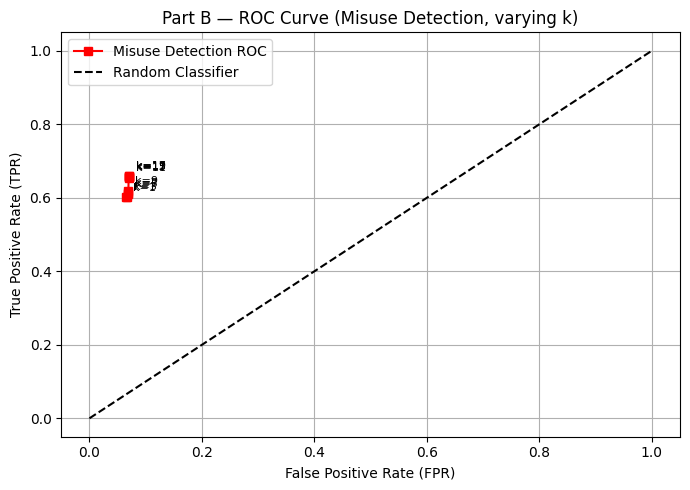


k   | FPR    | TPR
------------------------------
k= 1 | 0.0657 | 0.6008
k= 3 | 0.0674 | 0.6017
k= 5 | 0.0692 | 0.6095
k= 7 | 0.0690 | 0.6142
k= 9 | 0.0688 | 0.6186
k=11 | 0.0697 | 0.6532
k=13 | 0.0707 | 0.6554
k=15 | 0.0704 | 0.6558
k=17 | 0.0703 | 0.6592
k=19 | 0.0710 | 0.6595


In [10]:
# Sort by FPR so the curve draws correctly
sorted_B      = sorted(zip(fprs_B, tprs_B))
fprs_B_sorted = [p[0] for p in sorted_B]
tprs_B_sorted = [p[1] for p in sorted_B]

plt.figure(figsize=(7, 5))
plt.plot(fprs_B_sorted, tprs_B_sorted, 'rs-', label='Misuse Detection ROC')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

for k, fpr, tpr in zip(k_values, fprs_B, tprs_B):
    plt.annotate(f'k={k}', (fpr, tpr), textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Part B — ROC Curve (Misuse Detection, varying k)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nk   | FPR    | TPR")
print('-' * 30)
for k, fpr, tpr in zip(k_values, fprs_B, tprs_B):
    print(f"k={k:2d} | {fpr:.4f} | {tpr:.4f}")

### B(4) - AUC Calculation

In [11]:
auc_B = auc(fprs_B_sorted, tprs_B_sorted)
print(f"AUC (Part B - Misuse Detection): {auc_B:.4f}")

AUC (Part B - Misuse Detection): 0.0033


### B(5) - 5-class confusion matrix

Confusion Matrix (k=1, 5-class):


Predicted Label,normal,probe,dos,u2r,r2l
True Label,,,,,
normal,9073,163,469,2,4
probe,274,825,7,0,0
dos,304,106,5331,0,0
u2r,34,0,1,1,1
r2l,1973,154,5,0,67


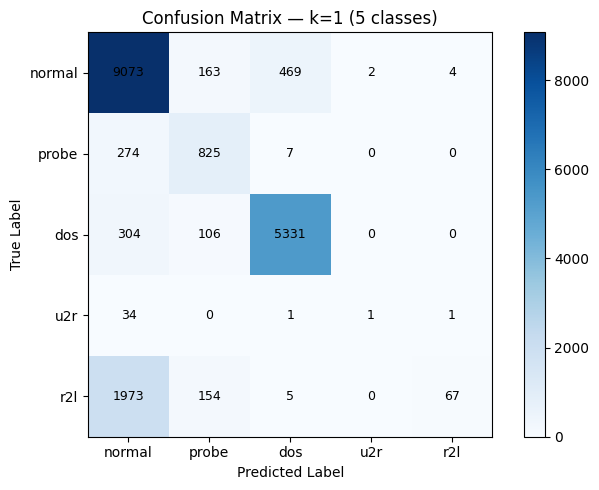

In [12]:
# Map labels to the 5 attack categories
y_train_cat = train_df['label'].apply(map_attack).values
y_test_cat  = test_df['label'].apply(map_attack).values

# Train k=1 classifier on all 5 categories
knn1 = KNeighborsClassifier(n_neighbors=1, metric='euclidean', n_jobs=-1)
knn1.fit(X_train_B, y_train_cat)
y_pred_cat = knn1.predict(X_test_B)

# Confusion matrix
cm_5  = confusion_matrix(y_test_cat, y_pred_cat, labels=CATEGORIES)
cm_df = pd.DataFrame(cm_5, index=CATEGORIES, columns=CATEGORIES)
cm_df.index.name   = 'True Label'
cm_df.columns.name = 'Predicted Label'

print("Confusion Matrix (k=1, 5-class):")
display(cm_df)

# Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm_5, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(CATEGORIES)))
ax.set_yticks(range(len(CATEGORIES)))
ax.set_xticklabels(CATEGORIES)
ax.set_yticklabels(CATEGORIES)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — k=1 (5 classes)')
for i in range(len(CATEGORIES)):
    for j in range(len(CATEGORIES)):
        ax.text(j, i, str(cm_5[i, j]), ha='center', va='center', color='black', fontsize=9)
plt.tight_layout()
plt.show()

### B(6) - KDD'99 cost score

In [13]:
total_cost = 0
num_valid  = 0

for true_label, pred_label in zip(y_test_cat, y_pred_cat):
    true_idx = cat_to_idx.get(true_label, -1)
    pred_idx = cat_to_idx.get(pred_label, -1)
    # Skip attack types not in our 5 categories
    if true_idx == -1 or pred_idx == -1:
        continue
    total_cost += COST_MATRIX[true_idx][pred_idx]
    num_valid  += 1

avg_cost = total_cost / num_valid

print(f"Total instances evaluated:  {num_valid:,}")
print(f"Total cost:                 {total_cost:,}")
print(f"Average cost per instance:  {avg_cost:.4f}")
print()
print("Reference scores:")
print("  KDD'99 contest winner: ~0.1906")
print("  Random classifier:     ~2.0")
print(f"  Our k=1 k-NN score:    {avg_cost:.4f}")


Total instances evaluated:  18,794
Total cost:                 10,857
Average cost per instance:  0.5777

Reference scores:
  KDD'99 contest winner: ~0.1906
  Random classifier:     ~2.0
  Our k=1 k-NN score:    0.5777
